# Beyond Last-Click: A Multi-Channel Performance Analysis in E-Commerce
## Notebook 01 — Data Collection, Validation & EDA

**Author:** Soheila Zamani  
**School:** SPICED Academy Berlin 2026  
**GitHub:** https://github.com/soheila-zamani/beyond-last-click

---

### What I do in this notebook

In this notebook, I start by loading both datasets and checking if the data is clean and usable.  
After that, I explore the data to understand patterns, missing values, and distributions.  

Finally, I create the first visual insights and prepare everything so it can be used later in SQL.

> **Note on dataset size:** This notebook documents the **raw 7,281-channel dataset** as collected from the YouTube Data API v3. The analysis dataset used in Notebooks 03–08 and in the published Tableau dashboards applies a `subscribers ≥ 1,000` filter (industry-standard nano tier lower bound), reducing the sample to **3,848 channels**. The raw EDA below shows the full collection before filtering — the filter step is applied in Notebook 02.

## 0. Setting up the environment (importing libraries)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Libraries loaded successfully
Pandas version: 2.3.3
NumPy version: 2.4.1


---
## PART 1 — YouTube API Dataset (Influencer Channel)
### 1.1 Load the data

In [14]:
# Load YouTube API dataset
df_yt = pd.read_csv('../02_Datasets/processed/youtube_influencers_clean.csv')

print('=== YOUTUBE API DATASET ===')
print(f'Shape: {df_yt.shape[0]:,} rows × {df_yt.shape[1]} columns')
print(f'\nColumn names:')
for col in df_yt.columns:
    print(f'  - {col}: {df_yt[col].dtype}')

=== YOUTUBE API DATASET ===
Shape: 7,281 rows × 10 columns

Column names:
  - channel_name: object
  - channel_id: object
  - subscribers: int64
  - total_views: int64
  - video_count: int64
  - avg_views_per_video: int64
  - view_per_subscriber: float64
  - country: object
  - tier: object
  - niche: object


In [15]:
# First look at the data
df_yt.head(10)

,channel_name,channel_id,subscribers,total_views,video_count,avg_views_per_video,view_per_subscriber,country,tier,niche
0,UBELLA,UCQmtEz5330JeLEIaoInalgA,6880,176444,36,4901,0.7124,ZA,nano,Beauty
1,PAINTEDBYSPENCER,UC0lj5odQ1wq2ZXgQKEZIx_Q,992000,88774510,188,472205,0.4760,US,macro,Beauty
2,Risa Does Makeup,UCVtgrv6KHBNcRxDTys9TCcQ,476000,57754188,1246,46352,0.0974,US,macro,Beauty
3,Nicola Chapman,UCjEPwaev8_zrpafISAPhruA,1990000,165306735,496,333280,0.1675,GB,mega,Beauty
4,Alicia Makeup Beauty,UCtJI-_10EBZkUObB4zaYsnQ,146000,21017224,498,42203,0.2891,FR,macro,Beauty
5,sophdoeslife,UC4X_adKmAQoBItCF0JWj_Hg,1410000,274559645,1191,230529,0.1635,GB,mega,Beauty
6,Makeup Tutorials With Andrèa💖,UCZ7AbqLBhLzRikyiCCwjvmg,3090,1002048,3242,309,0.1000,GB,nano,Beauty
7,Charlotte Tilbury Beauty,UCi0o9irT_KUpHmACT2VLiwg,885000,174450031,2286,76312,0.0862,GB,macro,Beauty
8,Alexandra Anele,UCzlgsdcnqJq8BDWY7bqWUmA,1420000,146789938,1000,146790,0.1034,US,mega,Beauty
9,Erica Taylor Beauty,UCwUG82Z94P_kuiq0e5pSxBg,35300,2674947,271,9871,0.2796,US,micro,Beauty


### 1.2 Data Quality Check

In [16]:
print('--- Checking data quality ---')
print(f'\n1. Missing values:')
print(df_yt.isnull().sum())

print(f'\n2. Duplicate channel IDs: {df_yt["channel_id"].duplicated().sum()}')

print(f'\n3. YouTube creators with 0 subscribers: {(df_yt["subscribers"] == 0).sum()}')

print(f'\n4. Subscriber range:')
print(f'   Min: {df_yt["subscribers"].min():,}')
print(f'   Max: {df_yt["subscribers"].max():,}')
print(f'   Mean: {df_yt["subscribers"].mean():,.0f}')
print(f'   Median: {df_yt["subscribers"].median():,.0f}')

--- Checking data quality ---

1. Missing values:
channel_name           0
channel_id             0
subscribers            0
total_views            0
video_count            0
avg_views_per_video    0
view_per_subscriber    0
country                0
tier                   0
niche                  0
dtype: int64

2. Duplicate channel IDs: 0

3. YouTube creators with 0 subscribers: 0

4. Subscriber range:
   Min: 1
   Max: 474,000,000
   Mean: 925,193
   Median: 4,500


In [17]:
# Clean: remove YouTube creators with 0 subscribers (cannot calculate engagement rate)
df_yt_clean = df_yt[df_yt['subscribers'] > 0].copy()
print(f'Rows before cleaning: {len(df_yt):,}')
print(f'Rows after cleaning: {len(df_yt_clean):,}')
print(f'Rows removed: {len(df_yt) - len(df_yt_clean)}')

Rows before cleaning: 7,281
Rows after cleaning: 7,281
Rows removed: 0


### 1.3 Tier Distribution

=== TIER DISTRIBUTION ===
tier
nano     3907
micro     965
macro    1339
mega     1070
Name: count, dtype: int64

Tier subscriber ranges:
  nano:  1 – 9,999 subscribers
  micro: 10,000 – 99,999 subscribers
  macro: 100,000 – 999,999 subscribers
  mega:  1,000,000+ subscribers


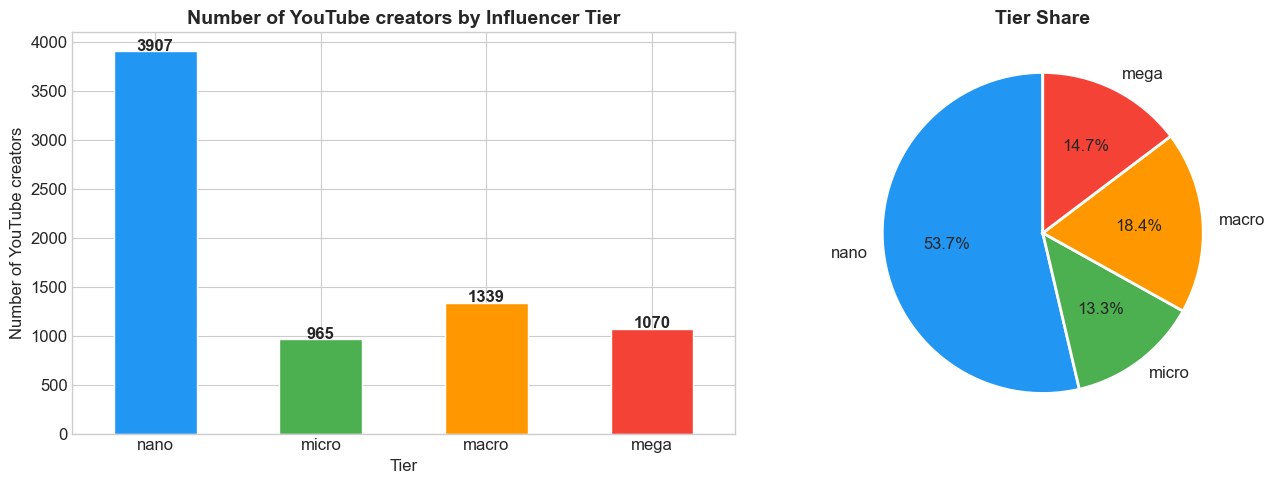

Chart saved


In [18]:
print('=== TIER DISTRIBUTION ===')
tier_counts = df_yt_clean['tier'].value_counts()
tier_order = ['nano', 'micro', 'macro', 'mega']
tier_counts = tier_counts.reindex(tier_order)

print(tier_counts)
print(f'\nTier subscriber ranges:')
print('  nano:  1 – 9,999 subscribers')
print('  micro: 10,000 – 99,999 subscribers')
print('  macro: 100,000 – 999,999 subscribers')
print('  mega:  1,000,000+ subscribers')

# Plot tier distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
tier_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Number of YouTube creators by Influencer Tier', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tier')
axes[0].set_ylabel('Number of YouTube creators')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(tier_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
tier_counts.plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%',
                 startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Tier Share', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../04_Analysis/01_tier_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

### 1.4 Niche Distribution

=== NICHE DISTRIBUTION ===
niche
Beauty              1274
Fashion             1095
Lifestyle            893
Film & Streaming     884
Fitness              800
Food                 736
Travel               593
Gaming               554
Shopping             452
Name: count, dtype: int64


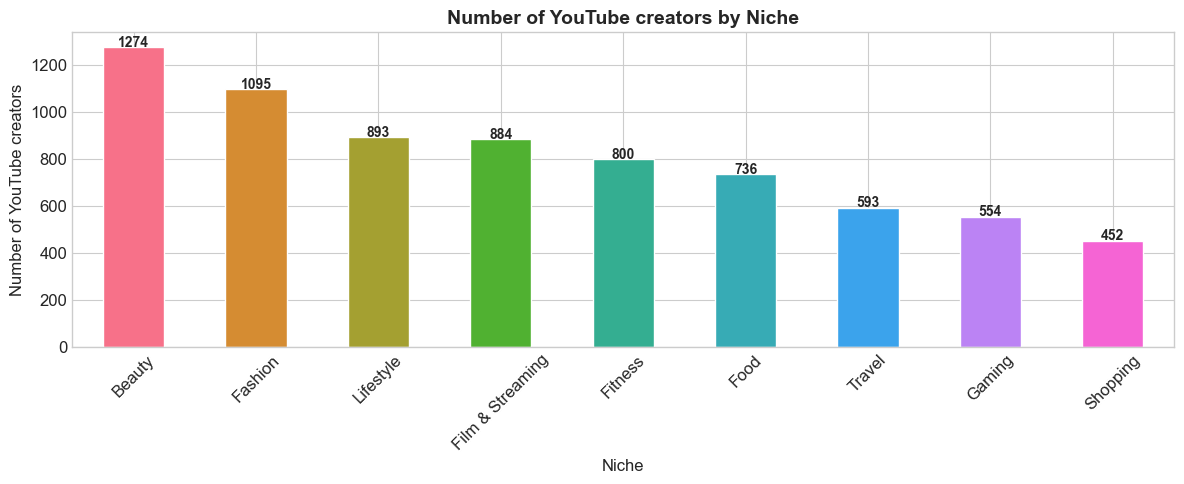

Chart saved


In [19]:
print('=== NICHE DISTRIBUTION ===')
niche_counts = df_yt_clean['niche'].value_counts()
print(niche_counts)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
niche_counts.plot(kind='bar', ax=ax, color=sns.color_palette('husl', len(niche_counts)),
                  edgecolor='white')
ax.set_title('Number of YouTube creators by Niche', fontsize=14, fontweight='bold')
ax.set_xlabel('Niche')
ax.set_ylabel('Number of YouTube creators')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(niche_counts):
    ax.text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../04_Analysis/02_niche_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

### 1.5 H1 — Engagement Rate by Tier (First Look)

=== H1: ENGAGEMENT RATE BY TIER ===
Metric: view_per_subscriber (avg views per video ÷ subscribers)

          mean  median       std  count
tier                                   
nano   29.2168  4.6266  166.5059   3907
micro   2.7229  0.7310   10.5314    965
macro   0.9933  0.4611    1.7155   1339
mega    0.5944  0.3276    0.9718   1070


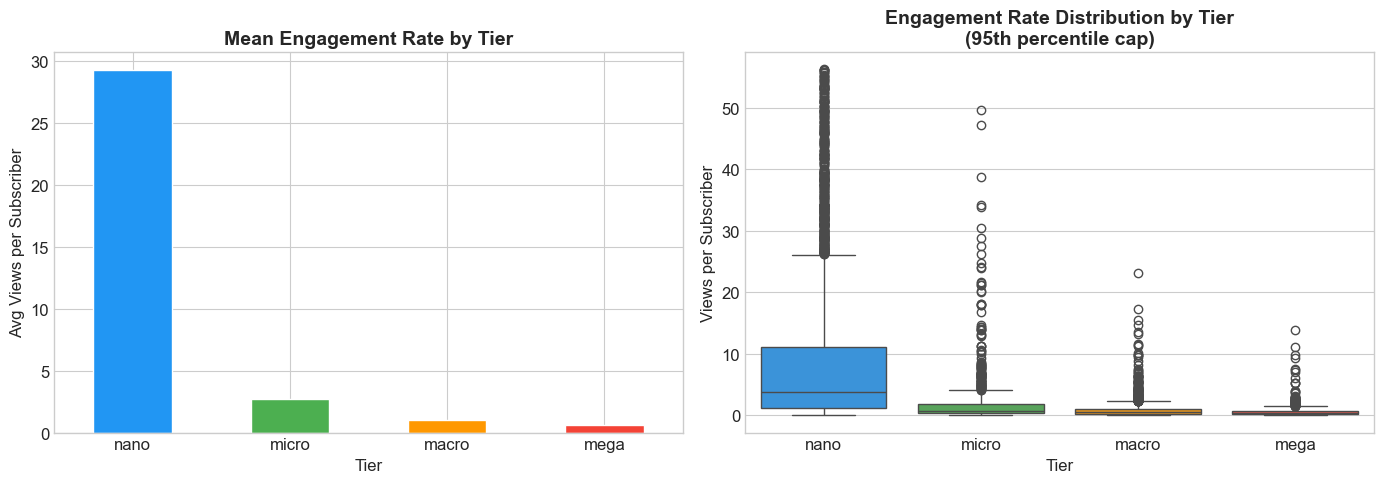

Chart saved


In [20]:
print('=== H1: ENGAGEMENT RATE BY TIER ===')
print('Metric: view_per_subscriber (avg views per video ÷ subscribers)')
print()

tier_engagement = df_yt_clean.groupby('tier')['view_per_subscriber'].agg([
    'mean', 'median', 'std', 'count'
]).round(4)
tier_engagement = tier_engagement.reindex(tier_order)
print(tier_engagement)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean engagement by tier
tier_means = df_yt_clean.groupby('tier')['view_per_subscriber'].mean().reindex(tier_order)
tier_means.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Mean Engagement Rate by Tier', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tier')
axes[0].set_ylabel('Avg Views per Subscriber')
axes[0].tick_params(axis='x', rotation=0)

# Boxplot
df_plot = df_yt_clean[df_yt_clean['view_per_subscriber'] < df_yt_clean['view_per_subscriber'].quantile(0.95)]
tier_order_present = [t for t in tier_order if t in df_plot['tier'].values]
df_plot['tier'] = pd.Categorical(df_plot['tier'], categories=tier_order_present, ordered=True)
df_plot_sorted = df_plot.sort_values('tier')
sns.boxplot(data=df_plot_sorted, x='tier', y='view_per_subscriber',
            palette=dict(zip(tier_order, colors)), ax=axes[1])
axes[1].set_title('Engagement Rate Distribution by Tier\n(95th percentile cap)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tier')
axes[1].set_ylabel('Views per Subscriber')

plt.tight_layout()
plt.savefig('../04_Analysis/03_h1_engagement_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

### 1.6 H2 — Engagement Rate by Niche (First Look)

=== H2: ENGAGEMENT RATE BY NICHE ===

                     mean  median  count
niche                                   
Fashion           32.8163  3.2934   1095
Shopping          24.6737  2.5805    452
Travel            20.8646  1.8476    593
Fitness           14.9670  0.5491    800
Beauty            14.3375  1.4886   1274
Film & Streaming  13.5055  1.1900    884
Gaming             9.1251  0.8221    554
Lifestyle          8.1102  1.2492    893
Food               6.5334  0.8680    736


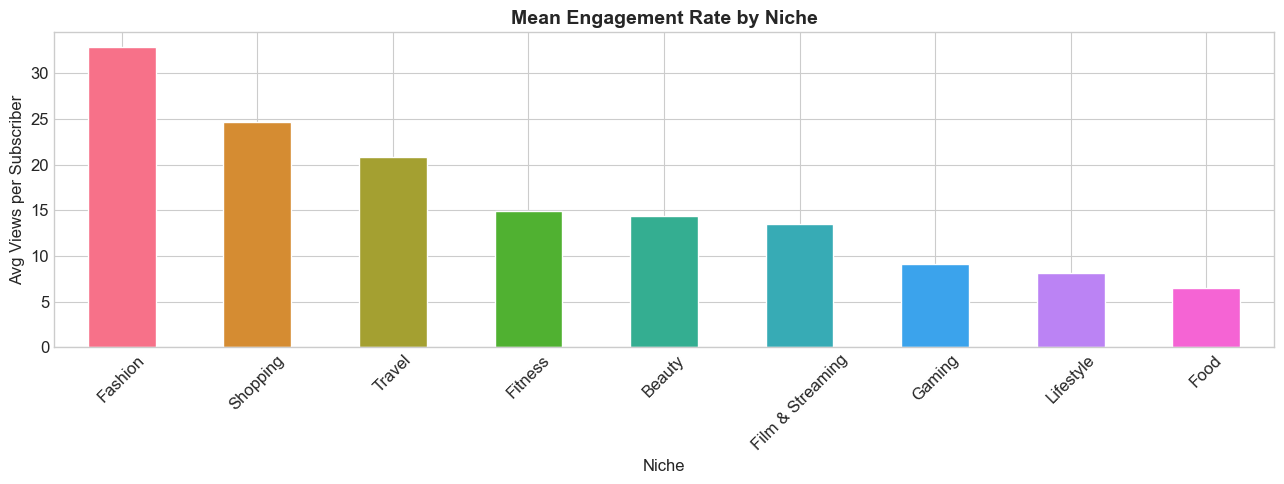

Chart saved


In [21]:
print('=== H2: ENGAGEMENT RATE BY NICHE ===')
print()

niche_engagement = df_yt_clean.groupby('niche')['view_per_subscriber'].agg([
    'mean', 'median', 'count'
]).round(4).sort_values('mean', ascending=False)
print(niche_engagement)

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
niche_engagement['mean'].plot(kind='bar', ax=ax,
                               color=sns.color_palette('husl', len(niche_engagement)),
                               edgecolor='white')
ax.set_title('Mean Engagement Rate by Niche', fontsize=14, fontweight='bold')
ax.set_xlabel('Niche')
ax.set_ylabel('Avg Views per Subscriber')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../04_Analysis/04_h2_engagement_by_niche.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

### 1.7 H3 — Subscriber Count vs Engagement (Correlation)

=== H3: SUBSCRIBER COUNT vs ENGAGEMENT EFFICIENCY ===

Pearson correlation (subscribers vs view_per_subscriber): -0.0177
→ Weak correlation: channel size has little effect on engagement rate


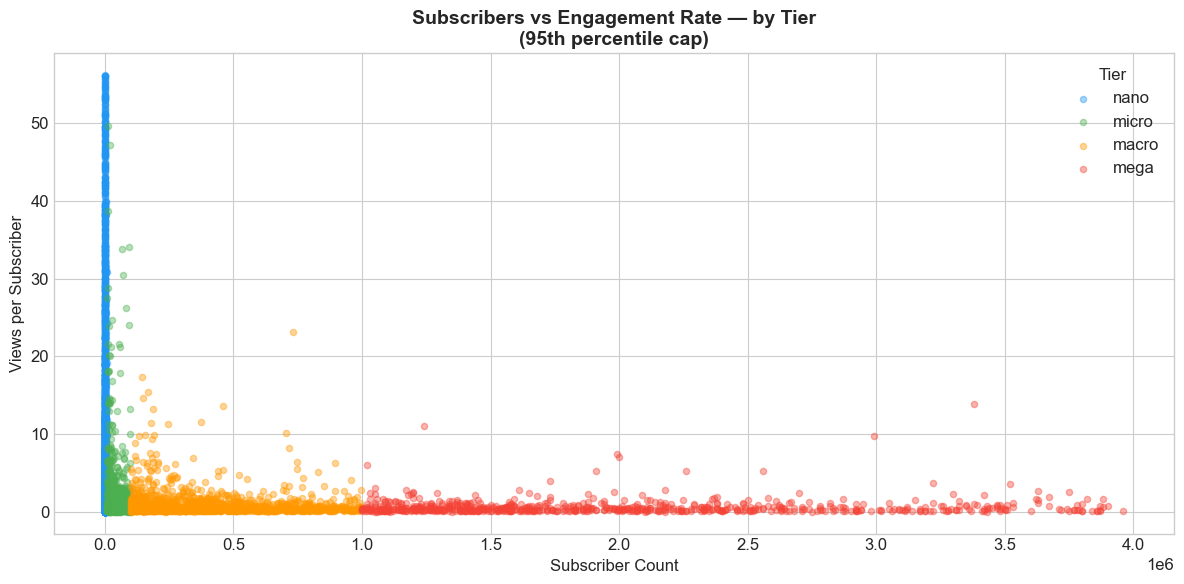

Chart saved


In [22]:
print('=== H3: SUBSCRIBER COUNT vs ENGAGEMENT EFFICIENCY ===')
print()

# Correlation
corr = df_yt_clean['subscribers'].corr(df_yt_clean['view_per_subscriber'])
print(f'Pearson correlation (subscribers vs view_per_subscriber): {corr:.4f}')
if corr < -0.1:
    print('→ Negative correlation: larger YouTube creators tend to have LOWER engagement per subscriber')
elif corr > 0.1:
    print('→ Positive correlation: larger YouTube creators tend to have HIGHER engagement per subscriber')
else:
    print('→ Weak correlation: channel size has little effect on engagement rate')

# Scatterplot (capped for readability)
df_scatter = df_yt_clean[
    (df_yt_clean['subscribers'] < df_yt_clean['subscribers'].quantile(0.95)) &
    (df_yt_clean['view_per_subscriber'] < df_yt_clean['view_per_subscriber'].quantile(0.95))
]

fig, ax = plt.subplots(figsize=(12, 6))
tier_color_map = {'nano': '#2196F3', 'micro': '#4CAF50', 'macro': '#FF9800', 'mega': '#F44336'}
for tier in tier_order:
    mask = df_scatter['tier'] == tier
    ax.scatter(df_scatter[mask]['subscribers'],
               df_scatter[mask]['view_per_subscriber'],
               alpha=0.4, s=20, label=tier, color=tier_color_map.get(tier))

ax.set_title('Subscribers vs Engagement Rate — by Tier\n(95th percentile cap)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Subscriber Count')
ax.set_ylabel('Views per Subscriber')
ax.legend(title='Tier')

plt.tight_layout()
plt.savefig('../04_Analysis/05_h3_subscribers_vs_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

---
## PART 2 — A/B Testing Dataset (Paid vs Organic)
### 2.1 Load the data

In [24]:
# Load A/B Testing dataset
df_ab = pd.read_csv('../02_Datasets/processed/ab_testing_clean.csv')

# Drop unnamed index column if exists
if 'Unnamed: 0' in df_ab.columns:
    df_ab = df_ab.drop(columns=['Unnamed: 0'])

print('=== A/B TESTING DATASET ===')
print(f'Shape: {df_ab.shape[0]:,} rows × {df_ab.shape[1]} columns')
print(f'\nColumns:')
for col in df_ab.columns:
    print(f'  - {col}: {df_ab[col].dtype}')

=== A/B TESTING DATASET ===
Shape: 588,101 rows × 6 columns

Columns:
  - user id: int64
  - test group: object
  - converted: bool
  - total ads: int64
  - most ads day: object
  - most ads hour: int64


In [25]:
df_ab.head(10)

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14
5,1137664,ad,False,734,Saturday,10
6,1116205,ad,False,264,Wednesday,13
7,1496843,ad,False,17,Sunday,18
8,1448851,ad,False,21,Tuesday,19
9,1446284,ad,False,142,Monday,14


### 2.2 Data Quality Check

In [26]:
print('=== DATA QUALITY CHECK ===')
print(f'\n1. Missing values:')
print(df_ab.isnull().sum())

print(f'\n2. Duplicate user IDs: {df_ab["user id"].duplicated().sum()}')

print(f'\n3. Test group distribution:')
print(df_ab['test group'].value_counts())

print(f'\n4. Conversion distribution:')
print(df_ab['converted'].value_counts())
print(f'Overall conversion rate: {df_ab["converted"].mean()*100:.2f}%')

=== DATA QUALITY CHECK ===

1. Missing values:
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

2. Duplicate user IDs: 0

3. Test group distribution:
test group
ad     564577
psa     23524
Name: count, dtype: int64

4. Conversion distribution:
converted
False    573258
True      14843
Name: count, dtype: int64
Overall conversion rate: 2.52%


### 2.3 H4 — Paid vs Organic Conversion Rate

In [27]:
print('=== H4: PAID vs ORGANIC CONVERSION RATE ===')
print()

# Conversion by group
conv_table = df_ab.groupby('test group')['converted'].agg(
    converted='sum',
    total='count',
    conversion_rate='mean'
).round(4)
conv_table['conversion_rate_pct'] = (conv_table['conversion_rate'] * 100).round(2)
print(conv_table)

# Extract values
paid_conv = df_ab[df_ab['test group'] == 'ad']['converted']
organic_conv = df_ab[df_ab['test group'] == 'psa']['converted']

paid_rate = paid_conv.mean() * 100
organic_rate = organic_conv.mean() * 100
lift = paid_rate / organic_rate

print(f'\nPaid conversion rate:    {paid_rate:.2f}%')
print(f'Organic conversion rate: {organic_rate:.2f}%')
print(f'Paid lift over organic:  {lift:.2f}x ({(lift-1)*100:.0f}% better)')

# Chi-square test
paid_yes = paid_conv.sum()
paid_no = len(paid_conv) - paid_yes
organic_yes = organic_conv.sum()
organic_no = len(organic_conv) - organic_yes

contingency = [[paid_yes, paid_no], [organic_yes, organic_no]]
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f'\n=== CHI-SQUARE TEST ===')
print(f'Chi2 statistic: {chi2:.2f}')
print(f'p-value: {p_value:.6f}')
print(f'Degrees of freedom: {dof}')
print()
if p_value < 0.05:
    print('RESULT: Statistically significant (p < 0.05)')
    print('→ H4 CONFIRMED: Paid advertising converts significantly better than organic')
else:
    print('RESULT: Not statistically significant (p >= 0.05)')
    print('H4 REJECTED: No significant difference between paid and organic')

=== H4: PAID vs ORGANIC CONVERSION RATE ===

            converted   total  conversion_rate  conversion_rate_pct
test group                                                         
ad              14423  564577           0.0255                 2.55
psa               420   23524           0.0179                 1.79

Paid conversion rate:    2.55%
Organic conversion rate: 1.79%
Paid lift over organic:  1.43x (43% better)

=== CHI-SQUARE TEST ===
Chi2 statistic: 54.01
p-value: 0.000000
Degrees of freedom: 1

RESULT: Statistically significant (p < 0.05)
→ H4 CONFIRMED: Paid advertising converts significantly better than organic


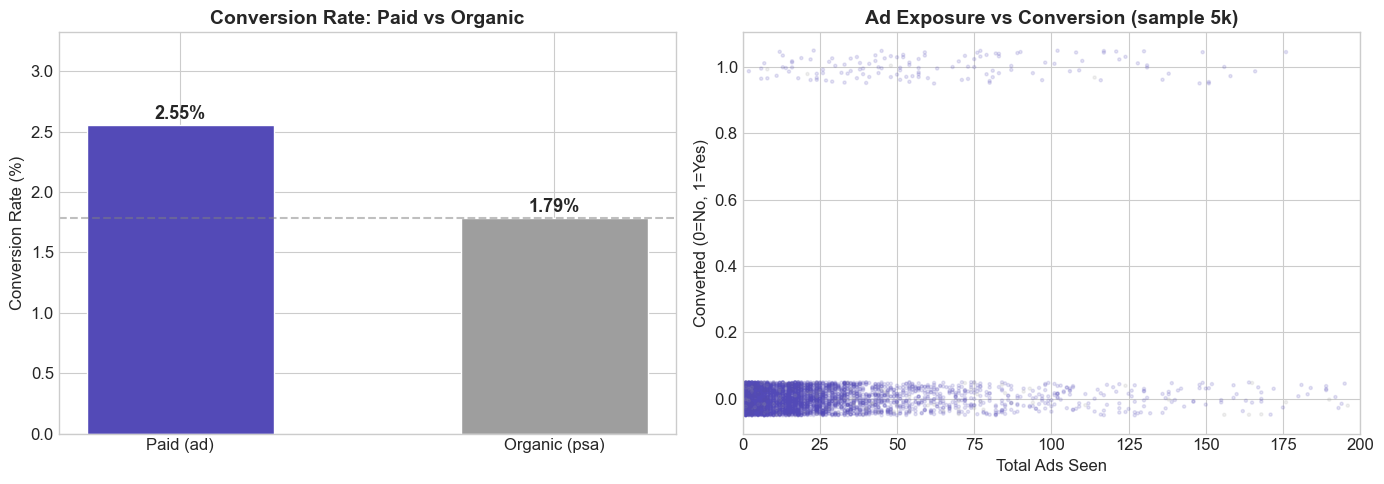

Chart saved


In [31]:
# Visualise paid vs organic
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conversion rate bar chart
groups = ['Paid (ad)', 'Organic (psa)']
rates = [paid_rate, organic_rate]
bar_colors = ['#534AB7', '#9E9E9E']

bars = axes[0].bar(groups, rates, color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_title('Conversion Rate: Paid vs Organic', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, max(rates) * 1.3)
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{rate:.2f}%', ha='center', fontsize=13, fontweight='bold')
axes[0].axhline(y=organic_rate, color='gray', linestyle='--', alpha=0.5, label='Organic baseline')

# Total ads vs conversion scatter
df_ab_sample = df_ab.sample(5000, random_state=42)
colors_ab = df_ab_sample['test group'].map({'ad': '#534AB7', 'psa': '#9E9E9E'})
axes[1].scatter(df_ab_sample['total ads'],
                df_ab_sample['converted'].astype(int) + np.random.uniform(-0.05, 0.05, len(df_ab_sample)),
                c=colors_ab, alpha=0.15, s=5)
axes[1].set_title('Ad Exposure vs Conversion (sample 5k)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Ads Seen')
axes[1].set_ylabel('Converted (0=No, 1=Yes)')
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.savefig('../04_Analysis/06_h4_paid_vs_organic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

### 2.4 Bonus — Best Day and Hour for Paid Ads

=== BONUS: BEST DAY AND HOUR FOR PAID ADS ===

Conversion rate by day:
most ads day
Monday       3.32
Tuesday      3.04
Wednesday    2.54
Thursday     2.16
Friday       2.25
Saturday     2.13
Sunday       2.46
Name: converted, dtype: float64


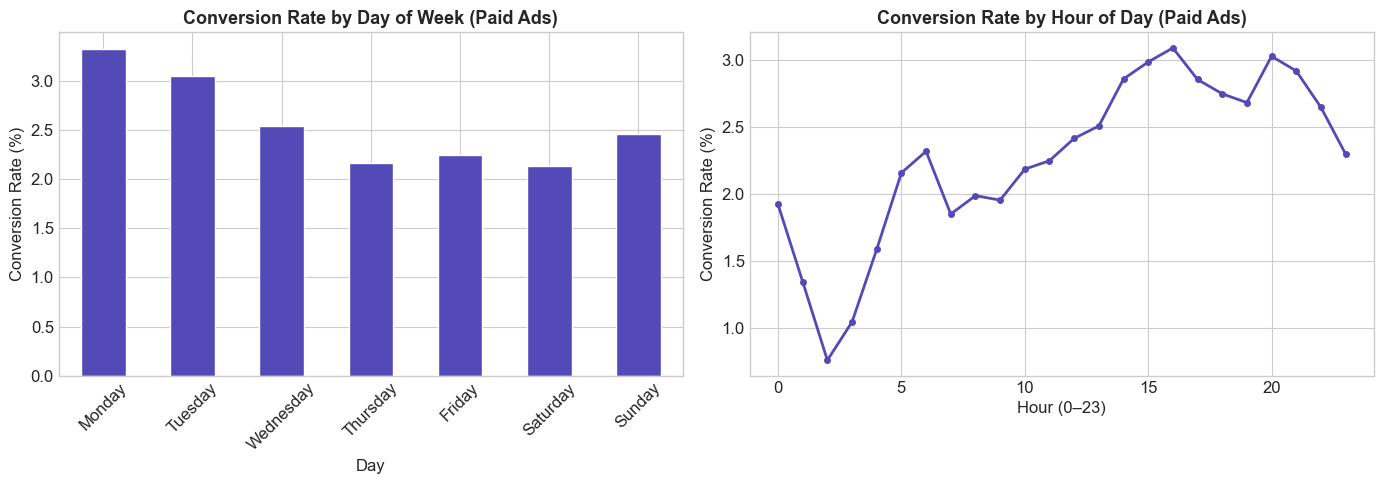

Chart saved


In [32]:
print('=== BONUS: BEST DAY AND HOUR FOR PAID ADS ===')
print()

df_ad = df_ab[df_ab['test group'] == 'ad']

# Conversion by day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_conv = df_ad.groupby('most ads day')['converted'].mean() * 100
day_conv = day_conv.reindex(day_order)
print('Conversion rate by day:')
print(day_conv.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day chart
day_conv.plot(kind='bar', ax=axes[0], color='#534AB7', edgecolor='white')
axes[0].set_title('Conversion Rate by Day of Week (Paid Ads)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Hour chart
hour_conv = df_ad.groupby('most ads hour')['converted'].mean() * 100
hour_conv.plot(kind='line', ax=axes[1], color='#534AB7', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Conversion Rate by Hour of Day (Paid Ads)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour (0–23)')
axes[1].set_ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.savefig('../04_Analysis/07_bonus_day_hour_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

---
## PART 3 — Summary
### 3.1 First insights from the data

#### Here are the main things I noticed when I explored the data for the first time.

In [33]:
print('=' * 60)
print('NOTEBOOK 01 SUMMARY — FIRST EDA RESULTS')
print('=' * 60)

print(f'''
DATASET 1 — YouTube API (Influencer Channel)
  Total YouTube creators:     {len(df_yt_clean):,}
  Tiers:              nano={len(df_yt_clean[df_yt_clean["tier"]=="nano"])}, 
                      micro={len(df_yt_clean[df_yt_clean["tier"]=="micro"])},
                      macro={len(df_yt_clean[df_yt_clean["tier"]=="macro"])},
                      mega={len(df_yt_clean[df_yt_clean["tier"]=="mega"])}
  Niches:             {df_yt_clean["niche"].nunique()} categories
  Countries:          {df_yt_clean["country"].nunique()} countries

DATASET 2 — A/B Testing (Paid vs Organic)
  Total users:        {len(df_ab):,}
  Paid group:         {len(df_ab[df_ab["test group"]=="ad"]):,} users
  Organic group:      {len(df_ab[df_ab["test group"]=="psa"]):,} users
  Paid conversion:    {paid_rate:.2f}%
  Organic conversion: {organic_rate:.2f}%
  Paid lift:          {lift:.2f}x better than organic
  H4 p-value:         {p_value:.6f} → {'CONFIRMED ✅' if p_value < 0.05 else 'REJECTED ❌'}

CHARTS SAVED:
  01_tier_distribution.png
  02_niche_distribution.png
  03_h1_engagement_by_tier.png
  04_h2_engagement_by_niche.png
  05_h3_subscribers_vs_engagement.png
  06_h4_paid_vs_organic.png
  07_bonus_day_hour_analysis.png

NEXT: Notebook 02 — Data Cleaning + Load into SQL
''')

print('=' * 60)

NOTEBOOK 01 SUMMARY — FIRST EDA RESULTS

DATASET 1 — YouTube API (Influencer Channel)
  Total YouTube creators:     7,281
  Tiers:              nano=3907, 
                      micro=965,
                      macro=1339,
                      mega=1070
  Niches:             9 categories
  Countries:          82 countries

DATASET 2 — A/B Testing (Paid vs Organic)
  Total users:        588,101
  Paid group:         564,577 users
  Organic group:      23,524 users
  Paid conversion:    2.55%
  Organic conversion: 1.79%
  Paid lift:          1.43x better than organic
  H4 p-value:         0.000000 → CONFIRMED ✅

CHARTS SAVED:
  01_tier_distribution.png
  02_niche_distribution.png
  03_h1_engagement_by_tier.png
  04_h2_engagement_by_niche.png
  05_h3_subscribers_vs_engagement.png
  06_h4_paid_vs_organic.png
  07_bonus_day_hour_analysis.png

NEXT: Notebook 02 — Data Cleaning + Load into SQL



---
### 3.2 Save cleaned datasets

In [36]:
# Save cleaned versions to processed folder
df_yt_clean.to_csv('../02_Datasets/processed/youtube_influencers_clean.csv', index=False)
df_ab.to_csv('../02_Datasets/processed/ab_testing_clean.csv', index=False)

print(' Cleaned datasets saved to 02_Datasets/processed/')
print(f' youtube_influencers_clean.csv — {len(df_yt_clean):,} rows')
print(f' ab_testing_clean.csv — {len(df_ab):,} rows')

 Cleaned datasets saved to 02_Datasets/processed/
 youtube_influencers_clean.csv — 7,281 rows
 ab_testing_clean.csv — 588,101 rows
